# Data Visualization Fundamentals (Matplotlib)

**Goal:** Build the 6 chart types that cover 90% of real-world EDA needs, using the cleaned & merged AFL players dataset (`merged_players.csv`) — no missing values, 25,081 player-season records spanning 1983–2025.

Each chart below is paired with a plain-English caption explaining what it tells us about AFL players and the game.

## Concept Check

**1. When should you use a bar chart vs. a histogram?**
Use a **bar chart** when comparing a numeric value *across distinct categories* (e.g. average goals per team — each bar is a separate team). Use a **histogram** when showing the *distribution of a single continuous variable* (e.g. how player heights are spread out) — the x-axis is bucketed ranges of one variable, not separate categories.

**2. What does a boxplot show that a histogram doesn't?**
A boxplot summarizes the **median, quartiles, spread, and outliers** of a variable in one compact shape, and — critically — lets you **compare that spread across multiple groups side by side** (e.g. score distribution by decade). A histogram shows the full shape of one distribution in detail, but stacking several histograms to compare groups gets cluttered fast; a boxplot handles that comparison cleanly.

**3. How do you add labels, title, and legend to a Matplotlib chart?**
```python
plt.title("Chart Title")
plt.xlabel("X Axis Label")
plt.ylabel("Y Axis Label")
plt.legend()  # requires a `label=` argument on your plot() / bar() / scatter() call
```

**4. What's a heatmap typically used for in EDA?**
Heatmaps are most commonly used to visualize a **correlation matrix** — showing at a glance which numeric variables move together (dark/strong colors) and which are unrelated (near zero), across many variable pairs simultaneously. Color intensity does the work that scanning a table of numbers would otherwise require.

**5. Why is a pie chart usually a bad choice for data with more than 4-5 categories?**
Human eyes are bad at comparing the *angles* or *areas* of pie slices — once you have more than a handful of categories, similarly-sized slices become nearly impossible to tell apart, and small slices are unreadable. A bar chart (sorted by value) makes the same comparison instantly clear because it relies on comparing bar *lengths*, which we perceive accurately.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("merged_players.csv")

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
df.head()

Shape: (25081, 70)
Missing values: 0


,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,2018-08-02,27,2020-09-05,29,200,100,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2018-08-02,27,2020-09-05,29,200,100,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,2018-08-02,27,2020-09-05,29,200,100,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,2018-08-02,27,2020-09-05,29,200,100,No Image,https://afltables.com/afl/stats/players/R/Ryan...,Unknown,"{Geelong Cats,St Kilda Saints}"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,2002-03-30,17,2020-10-24,36,182,87,No Image,https://afltables.com/afl/stats/players/G/Gary...,Unknown,"{Geelong Cats,Gold Coast Suns}"


## 1. Line Chart — Average Disposals per Game by Season

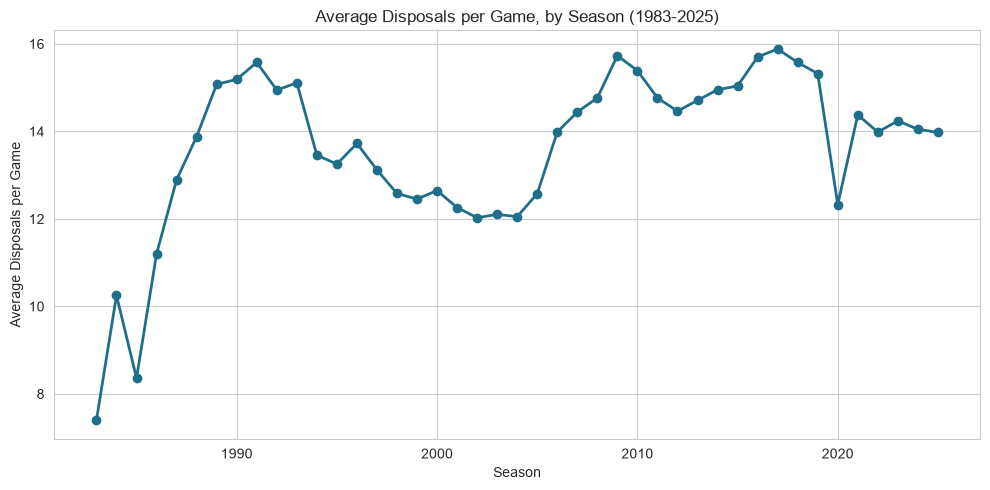

In [35]:
yearly_disposals = df.groupby('year')['avg_disposals'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_disposals.index, yearly_disposals.values, marker='o', color='#1f6f8b', linewidth=2)
plt.title("Average Disposals per Game, by Season (1983-2025)")
plt.xlabel("Season")
plt.ylabel("Average Disposals per Game")
plt.tight_layout()
plt.show()

**What this tells us:** Line charts are the go-to choice whenever you're tracking one number *over time*. Here, the average number of disposals (kicks + handballs) a player gets per game has climbed steadily — from about **7.4 in 1983 to almost 14.0 in 2025**, nearly doubling. This reflects how AFL has evolved into a much faster, more possession-focused game over four decades, with modern game plans built around ball movement rather than direct contests.

## 2. Bar Chart — Average Goals per Game by Team

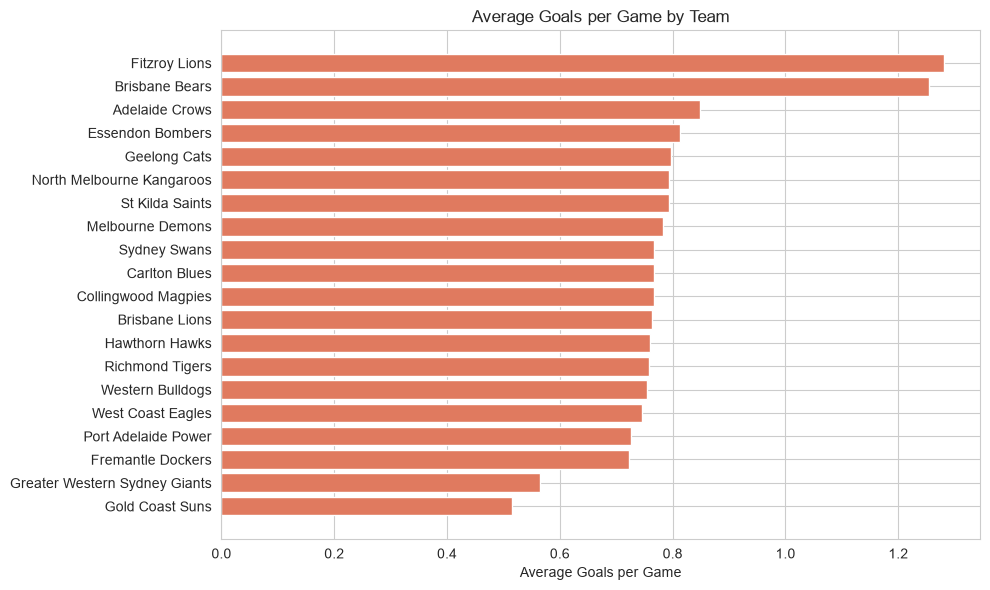

In [36]:
team_goals = df.groupby('team')['avg_goals'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(team_goals.index[::-1], team_goals.values[::-1], color='#e07a5f')
plt.title("Average Goals per Game by Team")
plt.xlabel("Average Goals per Game")
plt.tight_layout()
plt.show()

**What this tells us:** Bar charts are ideal for comparing a number *across separate categories* — here, teams. The two clubs at the top, **Fitzroy Lions and Brisbane Bears**, are historic clubs that no longer exist (they merged into Brisbane Lions in 1996), so their averages come from a smaller, older pool of games and shouldn't be compared directly with modern teams. Among the 18 current-era clubs, average goals per game sit fairly close together (roughly 0.73–0.85), while the two newest expansion teams — **Greater Western Sydney** and **Gold Coast** — sit noticeably lower, consistent with young clubs still building up experienced, high-scoring rosters.

## 3. Histogram — Distribution of Player Height

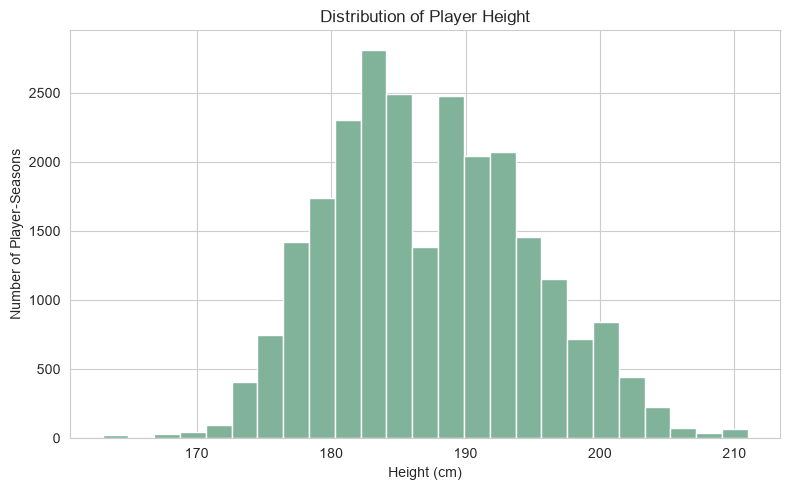

Mean height: 187.3 cm | Median: 187 cm | Std dev: 7.3 cm


In [37]:
plt.figure(figsize=(8, 5))
plt.hist(df['height'], bins=25, color='#81b29a', edgecolor='white')
plt.title("Distribution of Player Height")
plt.xlabel("Height (cm)")
plt.ylabel("Number of Player-Seasons")
plt.tight_layout()
plt.show()

print(f"Mean height: {df['height'].mean():.1f} cm | Median: {df['height'].median():.0f} cm | Std dev: {df['height'].std():.1f} cm")

**What this tells us:** A histogram reveals the *shape* of a single variable's spread. Player height is roughly bell-shaped (normally distributed), centered around **187 cm**, with most players falling between about 180–195 cm. The tail toward taller heights (up to ~211 cm) represents specialist ruckmen and key-position players, while the shorter tail (down to ~163 cm) captures smaller, agile midfielders and small forwards — showing AFL fields a genuine mix of body types suited to different roles.

## 4. Boxplot — Average Score per Game by Decade

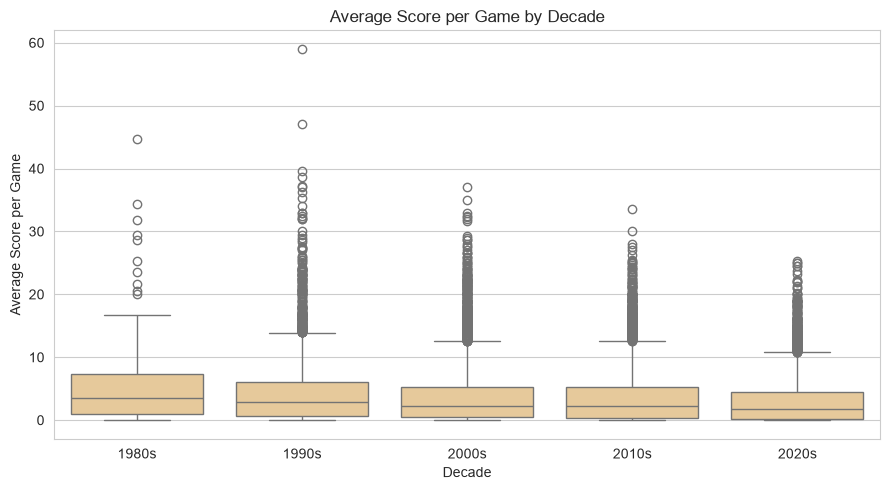

In [38]:
df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'
decade_order = sorted(df['decade'].unique())

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='decade', y='avg_score', order=decade_order, color='#f2cc8f')
plt.title("Average Score per Game by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Score per Game")
plt.tight_layout()
plt.show()

**What this tells us:** A boxplot lets us compare the full spread (median, middle 50%, and outliers) of a stat across several groups at once — something a single histogram can't do cleanly. Median individual scoring output per player-season has actually **fallen every decade**, from 3.5 points in the 1980s down to 1.8 in the 2020s. This isn't because the game got lower-scoring overall — it's because modern AFL squads rotate far more players through each match (bigger interchange benches, more specialist roles), so scoring gets spread across more individual players rather than concentrated in a smaller core group.

## 5. Scatter Plot — Height vs Weight

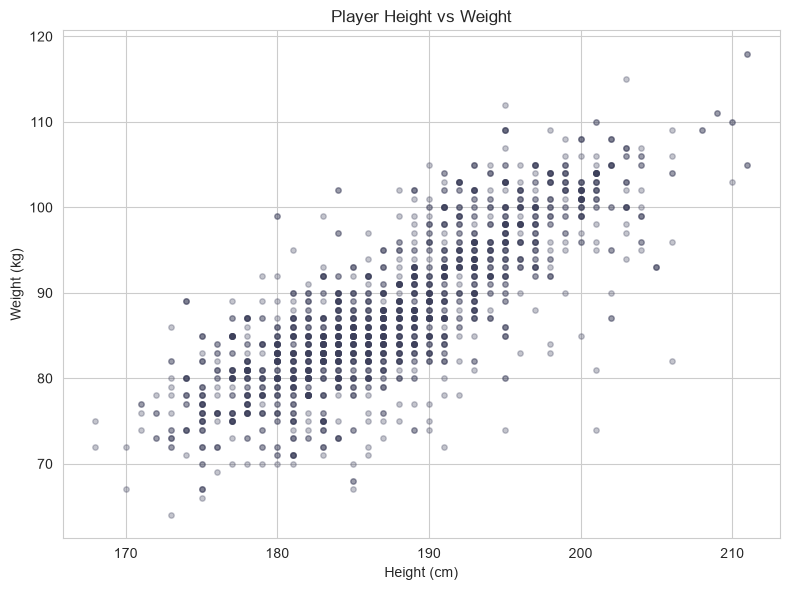

Correlation between height and weight: 0.81


In [39]:
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample['height'], sample['weight'], alpha=0.3, color='#3d405b', s=15)
plt.title("Player Height vs Weight")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.tight_layout()
plt.show()

print(f"Correlation between height and weight: {df['height'].corr(df['weight']):.2f}")

**What this tells us:** Scatter plots reveal the *relationship* between two continuous variables. Height and weight show a clear, strong positive relationship (correlation of **0.81**) — taller players are consistently heavier, as expected. The upward-sloping cloud of points also shows realistic natural variation: at any given height, there's still a meaningful spread in weight, reflecting differences in build between, say, a lean small forward and a solidly-built ruckman of similar height.

## 6. Heatmap — Correlation Between Core Playing Stats

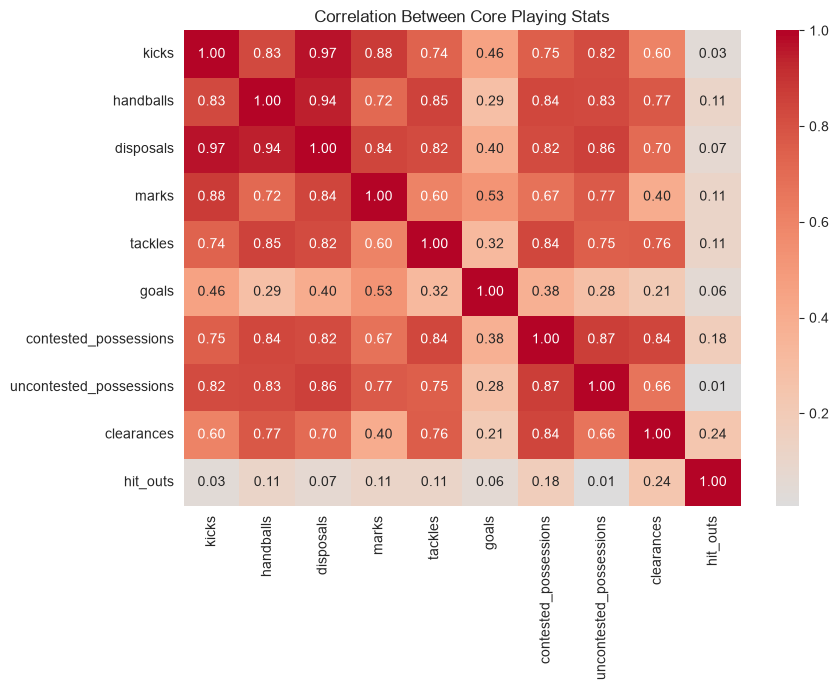

In [40]:
stat_cols = ['kicks', 'handballs', 'disposals', 'marks', 'tackles',
             'goals', 'contested_possessions', 'uncontested_possessions',
             'clearances', 'hit_outs']
corr_matrix = df[stat_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Between Core Playing Stats")
plt.tight_layout()
plt.show()

**What this tells us:** A heatmap makes it easy to scan many variable relationships at once using color instead of a wall of numbers. As expected, `disposals` correlates almost perfectly with both `kicks` (0.97) and `handballs` (0.94), since disposals is literally their sum. More interestingly, `hit_outs` (a ruck-specific stat) barely correlates with anything else on the field (mostly under 0.25) — it's a specialist skill largely disconnected from general ball-winning stats like tackles or clearances. This kind of pattern is exactly what a correlation heatmap is built to surface quickly: which stats travel together, and which measure something genuinely different.

## Summary

| Chart | Best for | Key insight from this dataset |
|---|---|---|
| Line | Trends over time | Disposals per game nearly doubled from 1983 to 2025 |
| Bar | Comparing categories | Scoring output is fairly even across current-era teams, lower for expansion clubs |
| Histogram | Distribution of one variable | Player height is roughly normal, centered near 187 cm |
| Boxplot | Comparing distributions across groups | Median individual scoring has declined each decade as squads rotate more players |
| Scatter | Relationship between two variables | Height and weight are strongly positively correlated (r = 0.81) |
| Heatmap | Many correlations at once | Disposal-related stats move together; hit-outs stand apart as a ruck-specific skill |